In [1]:
import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# Install dependencies
!pip install -q google-play-scraper tensorflow scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from google_play_scraper import reviews, Sort

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [4]:
APP_ID = 'id.dana'

result, continuation_token = reviews(
    APP_ID,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=50000
)

df_raw = pd.DataFrame(result)

print("Jumlah raw review:", len(df_raw))

df_raw.to_csv(
    'dana_raw_50000.csv',
    index=False,
    encoding='utf-8-sig'
)

Jumlah raw review: 50000


# Ambil kolom penting

In [5]:
df = df_raw[['content', 'score', 'at']].copy()

df.columns = [
    'review',
    'rating',
    'date'
]

print("Shape awal:", df.shape)
df.head()

Shape awal: (50000, 3)


,review,rating,date
0,👍,5,2026-09-07 01:08:40
1,"mantap ,cuman saya ga bisa pake dana cicil ,to...",5,2026-09-07 01:08:17
2,jlek masa sy kebobolan 488.000,2,2026-09-07 01:06:58
3,Minn tolong aktifkan saldo dana cicil saya aga...,4,2026-09-07 01:06:25
4,mantaaapppppp,5,2026-09-07 01:03:53


# Cleaning text

In [6]:
def clean_text(text):
    text = str(text).lower()

    # Hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # Hapus mention
    text = re.sub(r'@\w+', '', text)

    # Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df['clean_review'] = df['review'].apply(clean_text)

print("Missing review:", df['clean_review'].isna().sum())
print(
    "Empty review:",
    (df['clean_review'].str.strip() == '').sum()
)

Missing review: 0
Empty review: 0


# Hapus review kosong

In [7]:
df = df[
    df['clean_review'].str.strip() != ''
].copy()

df = df.reset_index(drop=True)

print("Jumlah data setelah cleaning:", len(df))

Jumlah data setelah cleaning: 50000


# Hapus duplicate

In [8]:
print(
    "Duplikat sebelum dedup:",
    df['clean_review'].duplicated().sum()
)

df = df.drop_duplicates(
    subset=['clean_review'],
    keep='first'
).reset_index(drop=True)

print(
    "Jumlah data setelah dedup:",
    len(df)
)

Duplikat sebelum dedup: 18529
Jumlah data setelah dedup: 31471


# Lihat distribusi rating

In [9]:
print(
    df['rating'].value_counts().sort_index()
)

rating
1    10767
2     1861
3     1783
4     1743
5    15317
Name: count, dtype: int64


# Filtering rating

In [10]:
df_binary = df[
    df['rating'].isin([1, 2, 4, 5])
].copy()

print(
    "Jumlah data setelah filtering rating:",
    len(df_binary)
)

Jumlah data setelah filtering rating: 29688


# Labeling

In [11]:
df_binary['sentiment'] = df_binary['rating'].apply(
    lambda x: 'negative' if x <= 2 else 'positive'
)

print(
    df_binary['sentiment'].value_counts()
)

sentiment
positive    17060
negative    12628
Name: count, dtype: int64


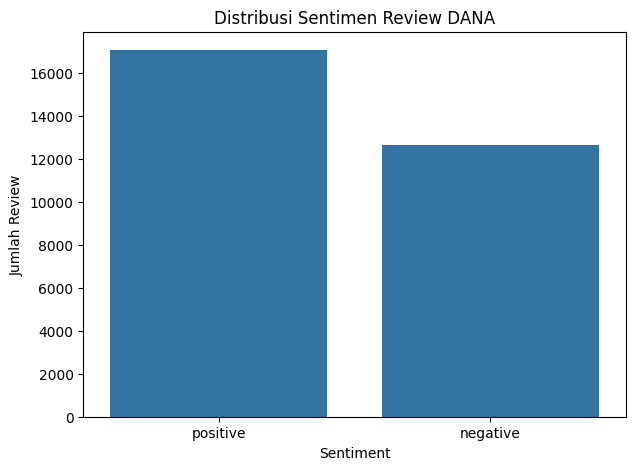

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_binary,
    x='sentiment'
)

plt.title('Distribusi Sentimen Review DANA')
plt.xlabel('Sentiment')
plt.ylabel('Jumlah Review')

plt.show()

In [13]:
df_final = df_binary[
    [
        'review',
        'clean_review',
        'rating',
        'date',
        'sentiment'
    ]
].copy()

print("Jumlah dataset final:", len(df_final))
print("\nDistribusi sentiment:")
print(df_final['sentiment'].value_counts())

Jumlah dataset final: 29688

Distribusi sentiment:
sentiment
positive    17060
negative    12628
Name: count, dtype: int64


In [14]:
df_final.to_csv(
    'dana_sentiment_dataset.csv',
    index=False,
    encoding='utf-8-sig'
)

print("Dataset berhasil disimpan.")

Dataset berhasil disimpan.


In [15]:
X = df_final['clean_review']
y = df_final['sentiment']

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))

Train      : 23750
Validation : 2969
Test       : 2969


In [17]:
print("TRAIN")
print(y_train.value_counts())

print("\nVALIDATION")
print(y_val.value_counts())

print("\nTEST")
print(y_test.value_counts())

TRAIN
sentiment
positive    13648
negative    10102
Name: count, dtype: int64

VALIDATION
sentiment
positive    1706
negative    1263
Name: count, dtype: int64

TEST
sentiment
positive    1706
negative    1263
Name: count, dtype: int64


In [18]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Class:", label_encoder.classes_)

Class: ['negative' 'positive']


In [19]:
MAX_WORDS = 20000
MAX_LEN = 50

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token='<OOV>'
)

tokenizer.fit_on_texts(X_train)

print(
    "Jumlah vocabulary:",
    len(tokenizer.word_index)
)

Jumlah vocabulary: 15474


# Konversi teks menjadi sequence

In [20]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding

In [21]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print("Train      :", X_train_pad.shape)
print("Validation :", X_val_pad.shape)
print("Test       :", X_test_pad.shape)

Train      : (23750, 50)
Validation : (2969, 50)
Test       : (2969, 50)


In [22]:
sample_idx = 0

print("Review asli:")
print(X_train.iloc[sample_idx])

print("\nSequence:")
print(X_train_seq[sample_idx])

print("\nSequence setelah padding:")
print(X_train_pad[sample_idx])

Review asli:
sangat bagus dan aman tetapi fitur dana cicil dan dana instan didak ada

Sequence:
[8, 18, 7, 60, 346, 39, 2, 12, 7, 2, 134, 6294, 10]

Sequence setelah padding:
[   8   18    7   60  346   39    2   12    7    2  134 6294   10    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


In [23]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    GRU,
    Dense,
    Dropout,
    Attention,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [24]:
inputs = Input(shape=(MAX_LEN,))

x = Embedding(
    input_dim=MAX_WORDS,
    output_dim=128
)(inputs)

x = Bidirectional(
    GRU(
        128,
        return_sequences=True
    )
)(x)

attention = Attention()([x, x])

x = GlobalAveragePooling1D()(attention)

x = Dense(
    64,
    activation='relu'
)(x)

x = Dropout(0.4)(x)

outputs = Dense(
    2,
    activation='softmax'
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs
)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 128)   │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 50, 256)   │    198,144 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 50, 256)   │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        130 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,774,722 (10.58 MB)

 Trainable params: 2,774,722 (10.58 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [26]:
history = model.fit(
    X_train_pad,
    y_train_encoded,
    validation_data=(
        X_val_pad,
        y_val_encoded
    ),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
743/743 ━━━━━━━━━━━━━━━━━━━━ 53s 66ms/step - accuracy: 0.8203 - loss: 0.4055 - val_accuracy: 0.8518 - val_loss: 0.3258
Epoch 2/15
743/743 ━━━━━━━━━━━━━━━━━━━━ 49s 66ms/step - accuracy: 0.8818 - loss: 0.2833 - val_accuracy: 0.8602 - val_loss: 0.3242
Epoch 3/15
743/743 ━━━━━━━━━━━━━━━━━━━━ 49s 66ms/step - accuracy: 0.9056 - loss: 0.2300 - val_accuracy: 0.8562 - val_loss: 0.3504
Epoch 4/15
743/743 ━━━━━━━━━━━━━━━━━━━━ 49s 65ms/step - accuracy: 0.9228 - loss: 0.1866 - val_accuracy: 0.8404 - val_loss: 0.4073
Epoch 5/15
743/743 ━━━━━━━━━━━━━━━━━━━━ 49s 66ms/step - accuracy: 0.9353 - loss: 0.1557 - val_accuracy: 0.8397 - val_loss: 0.4583


In [27]:
train_loss, train_acc = model.evaluate(
    X_train_pad,
    y_train_encoded,
    verbose=0
)

val_loss, val_acc = model.evaluate(
    X_val_pad,
    y_val_encoded,
    verbose=0
)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Train Loss          : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")

Train Accuracy      : 0.9133
Validation Accuracy : 0.8602
Train Loss          : 0.2180
Validation Loss     : 0.3242


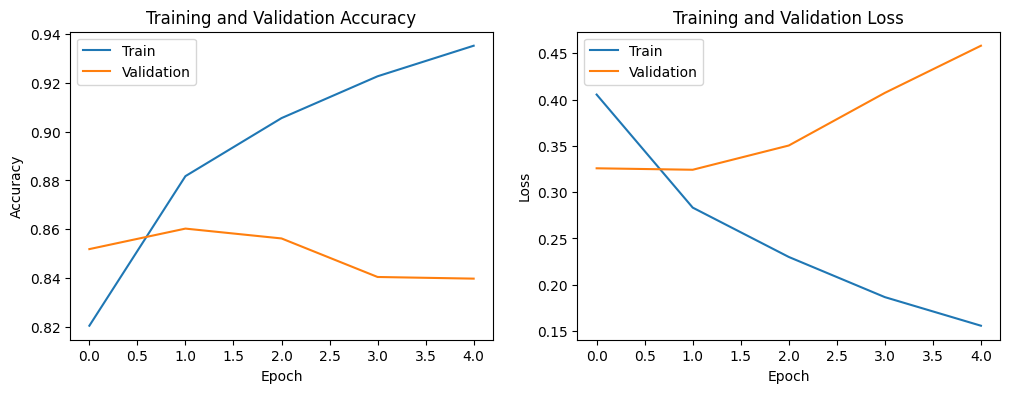

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)

plt.plot(
    history.history['accuracy'],
    label='Train'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation'
)

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)

plt.plot(
    history.history['loss'],
    label='Train'
)

plt.plot(
    history.history['val_loss'],
    label='Validation'
)

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [29]:
y_pred_prob = model.predict(
    X_test_pad,
    verbose=0
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

test_acc = accuracy_score(
    y_test_encoded,
    y_pred
)

print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Test Accuracy: 0.8565

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.86      0.84      1263
    positive       0.89      0.86      0.87      1706

    accuracy                           0.86      2969
   macro avg       0.85      0.86      0.85      2969
weighted avg       0.86      0.86      0.86      2969



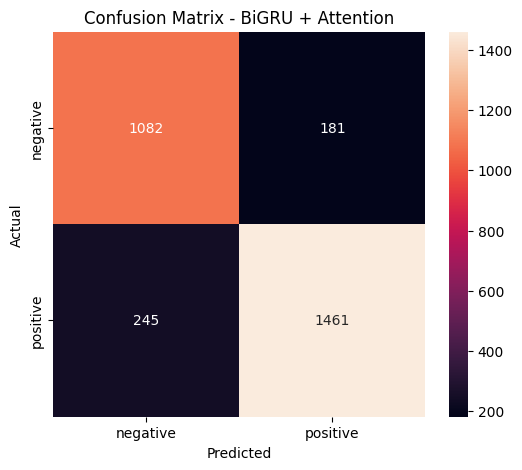

In [30]:
cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - BiGRU + Attention')

plt.show()

In [31]:
def predict_sentiment(text):
    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

    probability = model.predict(
        padded,
        verbose=0
    )[0]

    prediction = np.argmax(probability)

    label = label_encoder.inverse_transform(
        [prediction]
    )[0]

    confidence = probability[prediction]

    return label, float(confidence)

In [32]:
test_reviews = [
    "aplikasinya sangat bagus dan mudah digunakan",
    "dana saya sering error dan tidak bisa transfer",
    "transaksi di dana sangat cepat dan praktis",
    "aplikasinya sering gangguan dan tidak bisa dipakai"
]

for review in test_reviews:
    label, confidence = predict_sentiment(review)

    print("Review     :", review)
    print("Prediksi    :", label)
    print("Confidence :", round(confidence, 4))
    print("-" * 60)

Review     : aplikasinya sangat bagus dan mudah digunakan
Prediksi    : positive
Confidence : 0.9979
------------------------------------------------------------
Review     : dana saya sering error dan tidak bisa transfer
Prediksi    : negative
Confidence : 0.8117
------------------------------------------------------------
Review     : transaksi di dana sangat cepat dan praktis
Prediksi    : positive
Confidence : 0.9965
------------------------------------------------------------
Review     : aplikasinya sering gangguan dan tidak bisa dipakai
Prediksi    : negative
Confidence : 0.8657
------------------------------------------------------------


In [33]:
model.save(
    'dana_sentiment_model.keras'
)

In [34]:
import pickle

with open('dana_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [35]:
with open('dana_label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

## Kesimpulan

Model yang digunakan adalah Bidirectional GRU (BiGRU) dengan mekanisme
Attention untuk melakukan klasifikasi sentimen terhadap review aplikasi DANA.

Dataset diperoleh melalui scraping Google Play Store sebanyak 50.000 review.
Setelah proses cleaning, deduplikasi, dan filtering rating, diperoleh 29.694
data yang digunakan untuk pelatihan.

Label sentimen ditentukan berdasarkan rating:
- Rating 1–2: Negative
- Rating 4–5: Positive
- Rating 3: Tidak digunakan karena memiliki kecenderungan sentimen yang ambigu.

Dataset dibagi menjadi:
- 80% data training
- 10% data validation
- 10% data testing

Hasil evaluasi model:
- Training Accuracy: 91.33%
- Validation Accuracy: 86.02%
- Testing Accuracy: 85.65%

Testing accuracy sebesar 85.65% telah memenuhi batas minimum 85%.